# Challenge 10 — Análise de Dados: Transações Suspeitas

## Contexto

Uma plataforma de e-commerce divulgou um dataset com **50 transações** de clientes.
Há suspeita de que alguém inseriu uma **mensagem oculta** nos dados antes da publicação.

Sua missão: analisar o dataset, encontrar os registros anômalos e **decodificar a flag escondida**.

---

## Colunas do dataset

| Coluna | Descrição |
|---|---|
| `transaction_id` | Identificador da transação |
| `customer_id` | Identificador do cliente |
| `product` | Produto comprado |
| `total_amount` | Valor total da transação (R$) |
| `date` | Data da transação |

---

> **Dica:** preste atenção especial na coluna `total_amount`. Algo não está certo com alguns registros…

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Carregando e explorando os dados

In [2]:
df = pd.read_csv('transacoes.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (50, 5)


,transaction_id,customer_id,product,total_amount,date
0,TXN_01,user_01,Bola Futsal Penalty,935.00,2025-09-28
1,TXN_02,user_02,Tapete Persa Importado,5527.08,2025-07-14
2,TXN_03,user_03,Raquete Tênis Wilson,3890.00,2025-05-17
3,TXN_04,user_04,Bicicleta Speed Trek,22684.90,2024-01-03
4,TXN_05,user_05,Design Patterns - GoF,553.77,2024-04-10
5,TXN_06,user_06,Aspirador Electrolux,2295.03,2025-12-02
6,TXN_07,user_07,Panela de Pressão Tramontina,109.00,2025-02-10
7,TXN_08,user_08,Tênis Nike Air Max,116.00,2024-12-31
8,TXN_09,user_09,Luva Boxe Everlast,1579.98,2025-06-09
9,TXN_10,user_10,Python Fluente - Ramalho,636.96,2024-04-01


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  50 non-null     object 
 1   customer_id     50 non-null     object 
 2   product         50 non-null     object 
 3   total_amount    50 non-null     float64
 4   date            50 non-null     object 
dtypes: float64(1), object(4)
memory usage: 2.1+ KB


## 2. Estatísticas descritivas

In [4]:
df.describe()

,total_amount
count,50.000000
mean,4786.352200
std,7922.451126
min,98.000000
25%,1222.365000
50%,1877.920000
75%,3753.762500
max,36496.560000


## 3. Análise da distribuição de `total_amount`

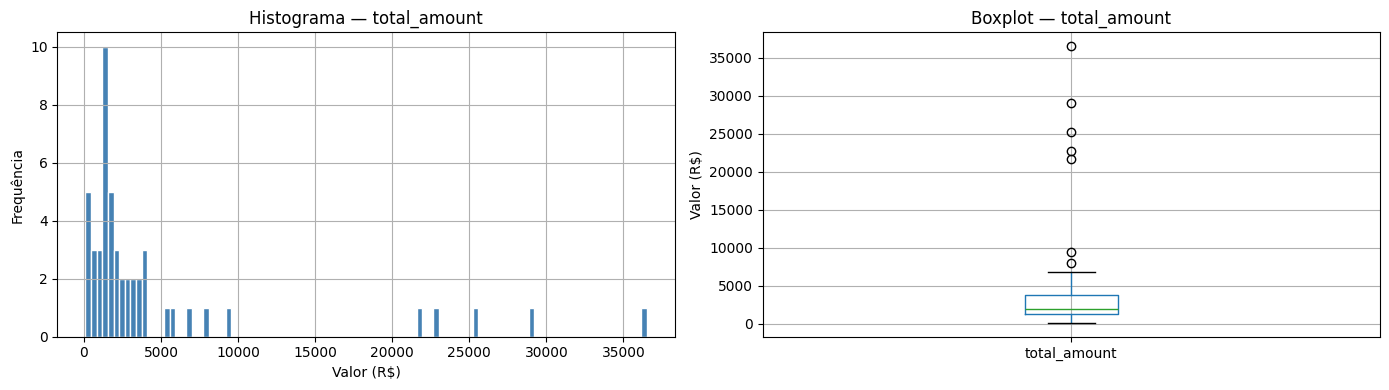

Mínimo: R$ 98.00
Máximo: R$ 36496.56
Mediana: R$ 1877.92


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['total_amount'].hist(bins=100, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Histograma — total_amount')
axes[0].set_xlabel('Valor (R$)')
axes[0].set_ylabel('Frequência')

df.boxplot(column='total_amount', ax=axes[1])
axes[1].set_title('Boxplot — total_amount')
axes[1].set_ylabel('Valor (R$)')

plt.tight_layout()
plt.show()

print(f"Mínimo: R$ {df['total_amount'].min():.2f}")
print(f"Máximo: R$ {df['total_amount'].max():.2f}")
print(f"Mediana: R$ {df['total_amount'].median():.2f}")

In [ ]:
df.sort_values('total_amount').head(25)

,transaction_id,customer_id,product,total_amount,date
20,TXN_21,user_21,Jogo de Cama 300 Fios,98.00,2025-09-29
6,TXN_07,user_07,Panela de Pressão Tramontina,109.00,2025-02-10
41,TXN_42,user_42,Fone Bluetooth JBL,109.00,2025-11-15
32,TXN_33,user_33,O Senhor dos Anéis,111.00,2024-11-20
7,TXN_08,user_08,Tênis Nike Air Max,116.00,2024-12-31
4,TXN_05,user_05,Design Patterns - GoF,553.77,2024-04-10
9,TXN_10,user_10,Python Fluente - Ramalho,636.96,2024-04-01
40,TXN_41,user_41,Design Patterns - GoF,772.76,2025-09-27
0,TXN_01,user_01,Bola Futsal Penalty,935.00,2025-09-28
36,TXN_37,user_37,Python Fluente - Ramalho,1115.35,2025-01-14


## 4. Identificando transações suspeitas

Os produtos custam no mínimo R$ 169,00 e a quantidade mínima é 3 — nenhuma transação legítima deveria ter `total_amount` abaixo de ~R$ 430.

Valores abaixo de R$ 200 são claramente anômalos.

In [7]:
THRESHOLD = 200

suspeitas = df[df['total_amount'] < THRESHOLD].copy()
print(f'Transações suspeitas encontradas: {len(suspeitas)}')
suspeitas

Transações suspeitas encontradas: 5


,transaction_id,customer_id,product,total_amount,date
6,TXN_07,user_07,Panela de Pressão Tramontina,109.0,2025-02-10
7,TXN_08,user_08,Tênis Nike Air Max,116.0,2024-12-31
20,TXN_21,user_21,Jogo de Cama 300 Fios,98.0,2025-09-29
32,TXN_33,user_33,O Senhor dos Anéis,111.0,2024-11-20
41,TXN_42,user_42,Fone Bluetooth JBL,109.0,2025-11-15


## 5. Decodificando a mensagem

Os valores de `total_amount` nas transações suspeitas parecem pequenos demais para qualquer produto real.
Será que são **códigos ASCII**?

Basta ordenar pelo `transaction_id` (que preserva a ordem de inserção) e converter cada valor para o caractere correspondente.

In [8]:
suspeitas_ord = suspeitas.sort_values('transaction_id')

print('Valores ASCII encontrados:')
print(suspeitas_ord['total_amount'].astype(int).tolist())

flag = ''.join(chr(int(v)) for v in suspeitas_ord['total_amount'])
print(f'\nFLAG: {flag}')

Valores ASCII encontrados:
[109, 116, 98, 111, 109]

FLAG: mtbom


---

## Resposta

```
mtbom
```